In [3]:
from NN_model_helper import (evaluate_fold_TL, set_freeze_mode, plot_training_progress, find_optimal_clusters)
from pathlib import Path
import sys
import pandas as pd
from sklearn.model_selection import StratifiedKFold
import numpy as np
from NN_model import ImprovedNN 

/opt/anaconda3/envs/Surabie_S_clean_v2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# classifier/ → MELTING_POINT_2026/
PROJECT_ROOT = Path.cwd().parent        # directory above a path: .../MELTING_POINT_2026

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

processed_dir = PROJECT_ROOT / "data_curation" / "processed_data"

df_path = PROJECT_ROOT / "Ro5" / "artifacts" / "full_data_50_50_no_interaction_scaled.parquet"
df = pd.read_parquet(df_path)

df.head()


,SMILES,MP,Ro5,RDKit_SMR_VSA2,RDKit_Kappa2,MACCS_41,RDKit_SMR_VSA6,RDKit_SlogP_VSA5,RDKit_VSA_EState7,RDKit_FpDensityMorgan2,...,RDKit_fr_Ar_NH,RDKit_Chi4n,RDKit_PEOE_VSA12,RDKit_NumAliphaticRings,MACCS_101,RDKit_TPSA,RDKit_fr_ArN,RDKit_fr_SH,RDKit_NumHeteroatoms,Type
0,CC(Oc1cc(N)c(cc1Cl)Cl)C,42.0,1,-0.246914,-0.318041,-0.252489,-0.037090,-0.264118,-0.305822,0.282657,...,-0.189949,-0.607761,-0.428275,-0.503703,-0.611085,-0.465382,2.929191,-0.081507,-0.151437,Train
1,Nc1ccc(cc1)S(=O)(=O)Nc1nnc(s1)C(C)(C)C,222.0,1,-0.246914,-0.027871,-0.252489,0.478583,0.213938,-0.319661,0.061296,...,-0.189949,-0.308585,0.926000,-0.503703,-0.611085,1.302247,2.929191,-0.081507,1.311127,Train
2,O=S1(=O)CCCCO1,13.5,1,-0.246914,-0.941911,-0.252489,0.686505,-0.304418,0.013022,0.636835,...,-0.189949,-0.765565,-0.428275,0.457273,-0.611085,-0.236538,-0.275426,-0.081507,-0.151437,Train
3,Cc1cc(C)c2c(c1)CC2=O,48.0,1,-0.246914,-0.968674,-0.252489,-0.663230,0.264803,-0.186582,0.636835,...,-0.189949,-0.092729,-0.428275,0.457273,1.636434,-0.977747,-0.275426,-0.081507,-1.248361,Train
4,C#CC1(CCCCC1)OC(=N)O,96.0,1,3.204934,-0.497337,-0.252489,-0.663230,0.467373,1.562280,0.636835,...,-0.189949,-0.191508,-0.428275,0.457273,-0.611085,0.043600,-0.275426,-0.081507,-0.517079,Train


In [9]:
df_bro5 = df[
    (df["Type"] == "Train") &
    (df["Ro5"] == 0)
].copy()

print("Shape:", df_bro5.shape)
print(df_bro5[["Type", "Ro5"]].value_counts())


Shape: (183, 105)
Type   Ro5
Train  0      183
Name: count, dtype: int64


In [10]:
df_bro5.head()

,SMILES,MP,Ro5,RDKit_SMR_VSA2,RDKit_Kappa2,MACCS_41,RDKit_SMR_VSA6,RDKit_SlogP_VSA5,RDKit_VSA_EState7,RDKit_FpDensityMorgan2,...,RDKit_fr_Ar_NH,RDKit_Chi4n,RDKit_PEOE_VSA12,RDKit_NumAliphaticRings,MACCS_101,RDKit_TPSA,RDKit_fr_ArN,RDKit_fr_SH,RDKit_NumHeteroatoms,Type
49,OCC1OC(Oc2c(oc3c(c2=O)c(O)cc(c3)OC)c2ccc(c(c2)...,187.0,0,-0.246914,2.207878,-0.252489,0.834689,-0.541532,-3.704046,-0.409599,...,-0.189949,1.873493,4.181811,1.418249,1.636434,5.824469,-0.275426,-0.081507,4.236256,Train
74,CC(CCCC(C1CCC2C1(C)CCC1C2CC(C2(C1(C)CCC(C2)OC(...,164.0,0,-0.246914,1.559489,-0.252489,-0.663230,3.952854,1.872290,-0.258447,...,-0.189949,4.803544,-0.428275,3.340202,1.636434,0.593730,-0.275426,-0.081507,0.214204,Train
86,Oc1ccc(cc1)c1oc2cc(O[C@@H]3O[C@@H](C)[C@@H]([C...,194.5,0,-0.246914,3.012081,-0.252489,0.058269,-0.264118,-5.121954,-1.266870,...,-0.189949,2.507936,5.841819,2.379225,1.636434,7.224875,-0.275426,-0.081507,5.333179,Train
207,N=C(NC(=N)Nc1ccc(cc1)Cl)NCCCCCCNC(=N)NC(=N)Nc1...,134.0,0,13.560479,2.896249,-0.252489,1.927431,0.210109,0.437800,-1.936161,...,-0.189949,0.529009,-0.428275,-0.503703,-0.611085,3.264056,-0.275426,-0.081507,2.773692,Train
277,C=CCOc1c(Br)cc(cc1Br)C(c1cc(Br)c(c(c1)Br)OCC=C...,119.0,0,-0.246914,1.419805,-0.252489,0.779768,0.181705,0.385561,-1.580054,...,-0.189949,0.398444,-0.428275,-0.503703,-0.611085,-0.938573,-0.275426,-0.081507,0.579845,Train


X_scaled shape: (183, 101)
Num features: 101


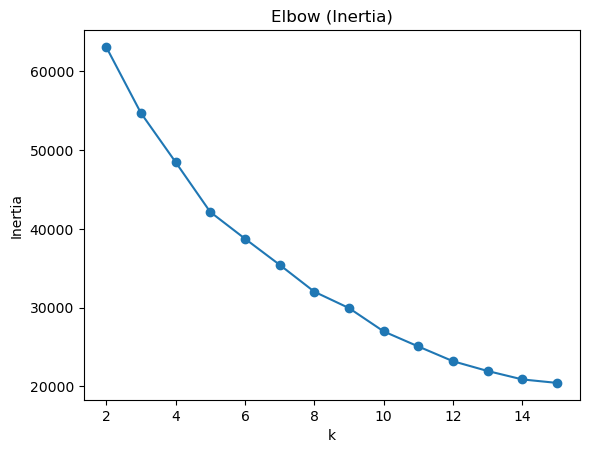

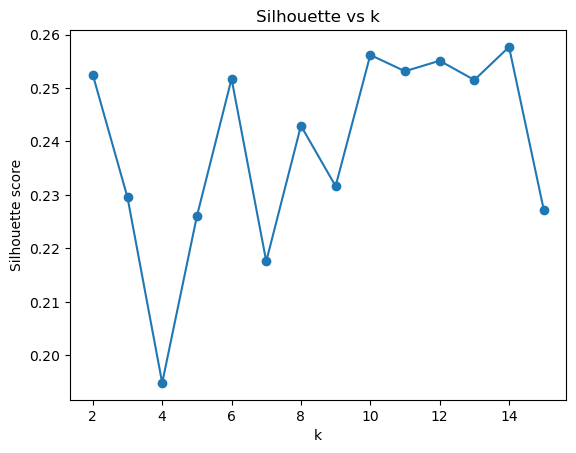

Elbow k: 8
Best silhouette k: 14


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

BASE = Path.cwd()
artifacts_dir = BASE / "artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 2) Define feature columns (already scaled)
#    Exclude metadata/labels/non-features
# -----------------------------
exclude = {"SMILES", "MP", "Type", "Ro5"}  # add any other non-features here
num_cols = df_bro5.select_dtypes(include=[np.number]).columns
feature_cols = [c for c in num_cols if c not in exclude]

X_scaled = df_bro5[feature_cols].to_numpy(dtype=np.float32)

print("X_scaled shape:", X_scaled.shape)
print("Num features:", len(feature_cols))

# -----------------------------
# 3) Find optimal k
# -----------------------------
def find_optimal_clusters(X_scaled, max_k=15, random_state=0, plot=True):
    ks = list(range(2, max_k + 1))
    inertias = []
    sils = []

    for k in ks:
        km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=random_state)
        labels = km.fit_predict(X_scaled)

        inertias.append(km.inertia_)
        sils.append(silhouette_score(X_scaled, labels))

    # elbow via kneed (works best when inertia curve is smooth)
    knee = KneeLocator(ks, inertias, curve="convex", direction="decreasing")
    k_elbow = knee.knee

    # silhouette best k
    k_sil = ks[int(np.argmax(sils))]

    if plot:
        plt.figure()
        plt.plot(ks, inertias, marker="o")
        plt.xlabel("k")
        plt.ylabel("Inertia")
        plt.title("Elbow (Inertia)")
        plt.show()

        plt.figure()
        plt.plot(ks, sils, marker="o")
        plt.xlabel("k")
        plt.ylabel("Silhouette score")
        plt.title("Silhouette vs k")
        plt.show()

        print("Elbow k:", k_elbow)
        print("Best silhouette k:", k_sil)

    # pick elbow if available; otherwise silhouette
    return k_elbow if k_elbow is not None else k_sil


random_state = 0
k_opt = find_optimal_clusters(X_scaled=X_scaled, max_k=15, random_state=random_state, plot=True)

if k_opt is None:
    k_opt = 3
    print("No clear elbow/silhouette; defaulting to k=3.")

# -----------------------------
# 4) Fit final kmeans + assign clusters
# -----------------------------
final_kmeans = KMeans(
    n_clusters=int(k_opt),
    init="k-means++",
    n_init=10,
    random_state=random_state
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

assert len(cluster_labels) == len(df_bro5), "Cluster labels length != df rows (mismatch)."

df_clustered = df_bro5.copy()
df_clustered["Structure_Cluster"] = cluster_labels


In [14]:
TARGET_COL = "MP"

exclude = {"SMILES", TARGET_COL, "Type", "Ro5", "Structure_Cluster"}
num_cols = df_clustered.select_dtypes(include=[np.number]).columns
feature_cols = [c for c in num_cols if c not in exclude]

X = df_clustered[feature_cols].to_numpy(np.float32) 
y = df_clustered[TARGET_COL].to_numpy(np.float32)
y_strat = df_clustered["Structure_Cluster"].astype(str).to_numpy()

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=10)
folds = [(tr, va) for tr, va in skf.split(X, y_strat)]

print("Total samples:", len(X))
print("Num features:", X.shape[1])
print("Num folds:", len(folds))
print()

for i, (tr_idx, va_idx) in enumerate(folds):
    print(
        f"Fold {i:2d} | "
        f"Train: {len(tr_idx):4d} | "
        f"Val: {len(va_idx):4d}"
    )


Total samples: 183
Num features: 101
Num folds: 10

Fold  0 | Train:  164 | Val:   19
Fold  1 | Train:  164 | Val:   19
Fold  2 | Train:  164 | Val:   19
Fold  3 | Train:  165 | Val:   18
Fold  4 | Train:  165 | Val:   18
Fold  5 | Train:  165 | Val:   18
Fold  6 | Train:  165 | Val:   18
Fold  7 | Train:  165 | Val:   18
Fold  8 | Train:  165 | Val:   18
Fold  9 | Train:  165 | Val:   18


/opt/anaconda3/envs/Surabie_S_clean_v2/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


In [17]:
from pathlib import Path
import json, joblib, numpy as np, pandas as pd, torch, optuna

BASELINE_CKPT = Path("artifacts/Ro5_best_models_no_interaction_50/Ro5_best_fold_1.pt")

# --- scenarios: name, vector (for your notes), freeze_level used by evaluate_fold_TL ---

HIDDEN_LAYERS = [192,96,48]   # must match baseline arch
N_TRIALS      = 20

OUT_ROOT = Path("artifacts/TL_Ro5_no_interaction_50")   # under the artifacts folder
OUT_ROOT.mkdir(parents=True, exist_ok=True)

def run_one_scenario(tag, freeze_vec, freeze_level):
    print(f"\n=== Scenario: {tag} | freeze={freeze_vec} (level={freeze_level}) ===")
    SCEN_OUT = OUT_ROOT / tag
    (SCEN_OUT / "trials").mkdir(parents=True, exist_ok=True)

    def objective_tl_fixed(trial):
        # fixed freeze level; tune the rest
        learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
        weight_decay  = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
        batch_size    = trial.suggest_categorical("batch_size", [16, 32, 64])
        dropout_rate  = trial.suggest_float("dropout_rate", 0.2, 0.5)

        trial_dir = SCEN_OUT / "trials" / f"trial_{trial.number:04d}"
        trial_dir.mkdir(parents=True, exist_ok=True)

        fold_metrics, rmses = [], []
        for fold_idx, (tr_idx, va_idx) in enumerate(folds):
            X_tr, y_tr = X[tr_idx], y[tr_idx]
            X_va, y_va = X[va_idx], y[va_idx]

            rmse, r2, q2, model, *_ = evaluate_fold_TL(
                trial=trial,
                fold_idx=fold_idx,
                X_train_scaled=X_tr, y_train=y_tr,
                X_val_scaled=X_va,   y_val=y_va,
                hidden_layers=HIDDEN_LAYERS, dropout_rate=dropout_rate,
                learning_rate=learning_rate, weight_decay=weight_decay,
                batch_size=batch_size, freeze_level=freeze_level,
                baseline_ckpt=BASELINE_CKPT,
                max_epochs=10**6, patience=30, min_delta=0.0,
                save_checkpoints=False
            )

            ckpt_path = trial_dir / f"fold_{fold_idx}_best.pth"
            torch.save(model.state_dict(), ckpt_path)

            fold_metrics.append({
                "fold": fold_idx,
                "rmse": float(rmse),
                "r2":   float(r2),
                "q2":   float(q2),
                "checkpoint": str(ckpt_path)
            })
            rmses.append(rmse)

        summary = {
            "scenario": tag,
            "freeze_vector": freeze_vec,
            "freeze_level": freeze_level,
            "trial_number": trial.number,
            "params": {
                "learning_rate": learning_rate,
                "weight_decay":  weight_decay,
                "batch_size":    batch_size,
                "dropout_rate":  dropout_rate,
                "hidden_layers": HIDDEN_LAYERS
            },
            "avg_rmse": float(np.mean(rmses)),
            "folds":    fold_metrics
        }
        with open(trial_dir / "summary.json", "w") as f:
            json.dump(summary, f, indent=2)

        return float(np.mean(rmses))

    # -- HPO
    study = optuna.create_study(direction="minimize")
    study.optimize(objective_tl_fixed, n_trials=N_TRIALS, gc_after_trial=True)

    # save study artifacts
    joblib.dump(study, SCEN_OUT / "study.joblib")
    study.trials_dataframe().to_csv(SCEN_OUT / "trials.csv", index=False)
    with open(SCEN_OUT / "best_params.json","w") as f:
        json.dump(study.best_params, f, indent=2)
    with open(SCEN_OUT / "best_value.txt","w") as f:
        f.write(f"{study.best_value:.6f}\n")
    print(f"[{tag}] Best avg RMSE: {study.best_value:.4f}")
    print(f"[{tag}] Best params:  {study.best_params}")

    # -- Final per-fold retrain with best params (to produce clean fold models + metrics)
    best = study.best_params
    FINAL_DIR = SCEN_OUT / "final_fold_models"
    FINAL_DIR.mkdir(parents=True, exist_ok=True)

    rows = []
    for fold_idx, (tr_idx, va_idx) in enumerate(folds):
        X_tr, y_tr = X[tr_idx], y[tr_idx]
        X_va, y_va = X[va_idx], y[va_idx]

        rmse, r2, q2, model, *_ = evaluate_fold_TL(
            trial=None,
            fold_idx=fold_idx,
            X_train_scaled=X_tr, y_train=y_tr,
            X_val_scaled=X_va,   y_val=y_va,
            hidden_layers=HIDDEN_LAYERS,
            dropout_rate=best["dropout_rate"],
            learning_rate=best["learning_rate"],
            weight_decay=best["weight_decay"],
            batch_size=best["batch_size"],
            freeze_level=freeze_level,
            baseline_ckpt=BASELINE_CKPT,
            max_epochs=10**6, patience=30, min_delta=0.0,
            save_checkpoints=False
        )

        ckpt = FINAL_DIR / f"fold_{fold_idx}_best.pth"
        torch.save(model.state_dict(), ckpt)
        rows.append({"fold": fold_idx, "rmse": float(rmse), "r2": float(r2), "q2": float(q2), "checkpoint": str(ckpt)})

    cv_df = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)
    cv_df.to_csv(SCEN_OUT / "cv_final_metrics.csv", index=False)

    best_row = cv_df.iloc[0]
    manifest = {
        "scenario": tag,
        "freeze_vector": freeze_vec,
        "freeze_level": freeze_level,
        "best_fold": int(best_row["fold"]),
        "checkpoint": best_row["checkpoint"],
        "hidden_layers": HIDDEN_LAYERS,
        "best_params": best
    }
    with open(SCEN_OUT / "manifest.json","w") as f:
        json.dump(manifest, f, indent=2)

    print(f"[{tag}] Best fold: {manifest['best_fold']} → {manifest['checkpoint']}")
    return study, cv_df, manifest


# ---------- RUN ALL THREE ----------
SCENARIOS = [
    ("no_freeze",        [0,0,0], 0),
    ("freeze_fc1",       [1,0,0], 1),
    ("freeze_fc1_fc2",   [1,1,0], 2),
]

results = {}
for tag, vec, lvl in SCENARIOS:
    study, cv_df, manifest = run_one_scenario(tag, vec, lvl)
    results[tag] = {"best": study.best_value, "manifest": manifest}
print("\nSummary:", json.dumps(results, indent=2))

[I 2026-02-11 08:56:14,147] A new study created in memory with name: no-name-4bca2b00-1ea0-4f6e-9ca1-9c844d8ca595



=== Scenario: no_freeze | freeze=[0, 0, 0] (level=0) ===
Fold 0: TL on cpu | freeze=0 | lr=0.000204399
Freeze Level 0: all layers trainable
[Fold 0] Epoch    1 | Train 79.6189 | Val 60.3219 | ES 0/30
[Fold 0] Early stopping at epoch 31 (best Val Loss: 60.3219)
Fold 1: TL on cpu | freeze=0 | lr=0.000204399
Freeze Level 0: all layers trainable
[Fold 1] Epoch    1 | Train 75.3114 | Val 48.9628 | ES 0/30


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/NN_model_helper.py:428: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(baseline_ckpt, map_location=d

[Fold 1] Early stopping at epoch 31 (best Val Loss: 48.9628)
Fold 2: TL on cpu | freeze=0 | lr=0.000204399
Freeze Level 0: all layers trainable
[Fold 2] Epoch    1 | Train 85.5214 | Val 46.7198 | ES 0/30


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/NN_model_helper.py:428: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(baseline_ckpt, map_location=d

...

/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/NN_model_helper.py:428: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(baseline_ckpt, map_location=d

[Fold 5] Early stopping at epoch 31 (best Val Loss: 34.6822)
Fold 6: TL on cpu | freeze=2 | lr=3.06497e-05
Freeze Level 2: freezing 2 block(s)
[Fold 6] Epoch    1 | Train 79.3479 | Val 61.9781 | ES 0/30
[Fold 6] Early stopping at epoch 31 (best Val Loss: 61.9781)
Fold 7: TL on cpu | freeze=2 | lr=3.06497e-05
Freeze Level 2: freezing 2 block(s)
[Fold 7] Epoch    1 | Train 85.3129 | Val 59.5771 | ES 0/30
[Fold 7] Early stopping at epoch 31 (best Val Loss: 59.5771)
Fold 8: TL on cpu | freeze=2 | lr=3.06497e-05
Freeze Level 2: freezing 2 block(s)
[Fold 8] Epoch    1 | Train 78.7206 | Val 38.5876 | ES 0/30


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/NN_model_helper.py:428: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(baseline_ckpt, map_location=d

[Fold 8] Early stopping at epoch 31 (best Val Loss: 38.5876)
Fold 9: TL on cpu | freeze=2 | lr=3.06497e-05
Freeze Level 2: freezing 2 block(s)
[Fold 9] Epoch    1 | Train 75.0830 | Val 66.2307 | ES 0/30
[Fold 9] Early stopping at epoch 31 (best Val Loss: 66.2307)
[freeze_fc1_fc2] Best fold: 5 → artifacts/TL_Ro5_no_interaction_50/freeze_fc1_fc2/final_fold_models/fold_5_best.pth

Summary: {
  "no_freeze": {
    "best": 48.396400451660156,
    "manifest": {
      "scenario": "no_freeze",
      "freeze_vector": [
        0,
        0,
        0
      ],
      "freeze_level": 0,
      "best_fold": 8,
      "checkpoint": "artifacts/TL_Ro5_no_interaction_50/no_freeze/final_fold_models/fold_8_best.pth",
      "hidden_layers": [
        192,
        96,
        48
      ],
      "best_params": {
        "learning_rate": 0.0009627537794837015,
        "weight_decay": 0.000805525679287793,
        "batch_size": 16,
        "dropout_rate": 0.32566416033778345
      }
    }
  },
  "freeze_fc1": {
 

/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/NN_model_helper.py:428: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(baseline_ckpt, map_location=d

In [18]:
from NN_model import ImprovedNN
import torch
import pandas as pd
from pathlib import Path
import json

def load_best_models_for_scenarios(
    root_dir="artifacts/TL_Ro5_no_interaction_50",
    scenarios=("no_freeze", "freeze_fc1", "freeze_fc1_fc2"),
):
    root_dir = Path(root_dir)
    models = {}
    manifests = {}

    for tag in scenarios:
        manifest_path = root_dir / tag / "manifest.json"
        cv_metrics_path = root_dir / tag / "cv_final_metrics.csv"

        # Load manifest
        with open(manifest_path, "r") as f:
            manifest = json.load(f)
        manifests[tag] = manifest

        # Load best RMSE from cv_final_metrics.csv
        cv_df = pd.read_csv(cv_metrics_path)
        best_row = cv_df.sort_values("rmse").iloc[0]
        best_rmse = float(best_row["rmse"])

        # Load checkpoint
        ckpt_path = Path(best_row["checkpoint"]).resolve()
        state = torch.load(ckpt_path, map_location="cpu")

        # Build model
        input_size = state["network.0.weight"].shape[1]
        hidden_layers = manifest["hidden_layers"]
        dropout_rate = manifest["best_params"]["dropout_rate"]

        model = ImprovedNN(
            input_size=input_size,
            hidden_layers=hidden_layers,
            dropout_rate=dropout_rate,
        )
        model.load_state_dict(state)
        model.eval()

        models[tag] = model

        print(f"Loaded model for scenario '{tag}'")
        print(f"  └─ Best fold checkpoint: {ckpt_path}")
        print(f"  └─ Best RMSE: {best_rmse:.4f}\n")

    return models, manifests

models, manifests = load_best_models_for_scenarios(
    root_dir="artifacts/TL_Ro5_no_interaction",
    scenarios=["no_freeze", "freeze_fc1", "freeze_fc1_fc2"]
)

Loaded model for scenario 'no_freeze'
  └─ Best fold checkpoint: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/TL_Ro5_no_interaction/no_freeze/final_fold_models/fold_2_best.pth
  └─ Best RMSE: 28.9620

Loaded model for scenario 'freeze_fc1'
  └─ Best fold checkpoint: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/TL_Ro5_no_interaction/freeze_fc1/final_fold_models/fold_2_best.pth
  └─ Best RMSE: 25.2650

Loaded model for scenario 'freeze_fc1_fc2'
  └─ Best fold checkpoint: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/TL_Ro5_no_interaction/freeze_fc1_fc2/final_fold_models/fold_9_best.pth
  └─ Best RMSE: 32.2158



/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_85276/54998067.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt_path, map_location="cp

In [19]:
import pandas as pd
from pathlib import Path

def print_rmse_all_folds(
    root_dir="artifacts/TL_Ro5_no_interaction_50",
    scenarios=("no_freeze", "freeze_fc1", "freeze_fc1_fc2"),
):
    root_dir = Path(root_dir)

    for tag in scenarios:
        cv_metrics_path = root_dir / tag / "cv_final_metrics.csv"

        if not cv_metrics_path.exists():
            print(f"[WARN] Missing CV metrics for scenario '{tag}'")
            continue

        cv_df = pd.read_csv(cv_metrics_path)

        print(f"\nScenario: {tag}")
        print("-" * (10 + len(tag)))

        # Expecting columns like: fold, rmse, r2, q2, checkpoint, ...
        for _, row in cv_df.iterrows():
            fold = row.get("fold", "N/A")
            rmse = row["rmse"]
            print(f"  Fold {fold}: RMSE = {rmse:.4f}")

        print(f"  Mean RMSE: {cv_df['rmse'].mean():.4f}")
        print(f"  Std  RMSE: {cv_df['rmse'].std():.4f}")

# Run it
print_rmse_all_folds(
    root_dir="artifacts/TL_Ro5_no_interaction_50",
    scenarios=["no_freeze", "freeze_fc1", "freeze_fc1_fc2"]
)


Scenario: no_freeze
-------------------
  Fold 8: RMSE = 36.3690
  Fold 7: RMSE = 38.4089
  Fold 3: RMSE = 44.9099
  Fold 1: RMSE = 50.8277
  Fold 5: RMSE = 51.1216
  Fold 0: RMSE = 51.3853
  Fold 6: RMSE = 51.6989
  Fold 2: RMSE = 54.3483
  Fold 4: RMSE = 59.4238
  Fold 9: RMSE = 61.0947
  Mean RMSE: 49.9588
  Std  RMSE: 8.0527

Scenario: freeze_fc1
--------------------
  Fold 5: RMSE = 34.8042
  Fold 8: RMSE = 38.2663
  Fold 1: RMSE = 49.6904
  Fold 0: RMSE = 52.8352
  Fold 3: RMSE = 55.8153
  Fold 4: RMSE = 57.1569
  Fold 7: RMSE = 60.2132
  Fold 6: RMSE = 61.0734
  Fold 2: RMSE = 64.0502
  Fold 9: RMSE = 66.2922
  Mean RMSE: 54.0197
  Std  RMSE: 10.4879

Scenario: freeze_fc1_fc2
------------------------
  Fold 5: RMSE = 34.6822
  Fold 8: RMSE = 38.5876
  Fold 1: RMSE = 50.0001
  Fold 0: RMSE = 52.8255
  Fold 3: RMSE = 55.5301
  Fold 4: RMSE = 56.4835
  Fold 7: RMSE = 59.5771
  Fold 6: RMSE = 61.9781
  Fold 9: RMSE = 66.2307
  Fold 2: RMSE = 67.3714
  Mean RMSE: 54.3266
  Std  RMSE

TEST EVALUATION

In [20]:
# classifier/ → MELTING_POINT_2026/
PROJECT_ROOT = Path.cwd().parent        # directory above a path: .../MELTING_POINT_2026

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

processed_dir = PROJECT_ROOT / "data_curation" / "processed_data"

df_path = PROJECT_ROOT / "Ro5" / "artifacts" / "full_data_50_50_no_interaction_scaled.parquet"
df = pd.read_parquet(df_path)

df.head()

,SMILES,MP,Ro5,RDKit_SMR_VSA2,RDKit_Kappa2,MACCS_41,RDKit_SMR_VSA6,RDKit_SlogP_VSA5,RDKit_VSA_EState7,RDKit_FpDensityMorgan2,...,RDKit_fr_Ar_NH,RDKit_Chi4n,RDKit_PEOE_VSA12,RDKit_NumAliphaticRings,MACCS_101,RDKit_TPSA,RDKit_fr_ArN,RDKit_fr_SH,RDKit_NumHeteroatoms,Type
0,CC(Oc1cc(N)c(cc1Cl)Cl)C,42.0,1,-0.246914,-0.318041,-0.252489,-0.037090,-0.264118,-0.305822,0.282657,...,-0.189949,-0.607761,-0.428275,-0.503703,-0.611085,-0.465382,2.929191,-0.081507,-0.151437,Train
1,Nc1ccc(cc1)S(=O)(=O)Nc1nnc(s1)C(C)(C)C,222.0,1,-0.246914,-0.027871,-0.252489,0.478583,0.213938,-0.319661,0.061296,...,-0.189949,-0.308585,0.926000,-0.503703,-0.611085,1.302247,2.929191,-0.081507,1.311127,Train
2,O=S1(=O)CCCCO1,13.5,1,-0.246914,-0.941911,-0.252489,0.686505,-0.304418,0.013022,0.636835,...,-0.189949,-0.765565,-0.428275,0.457273,-0.611085,-0.236538,-0.275426,-0.081507,-0.151437,Train
3,Cc1cc(C)c2c(c1)CC2=O,48.0,1,-0.246914,-0.968674,-0.252489,-0.663230,0.264803,-0.186582,0.636835,...,-0.189949,-0.092729,-0.428275,0.457273,1.636434,-0.977747,-0.275426,-0.081507,-1.248361,Train
4,C#CC1(CCCCC1)OC(=N)O,96.0,1,3.204934,-0.497337,-0.252489,-0.663230,0.467373,1.562280,0.636835,...,-0.189949,-0.191508,-0.428275,0.457273,-0.611085,0.043600,-0.275426,-0.081507,-0.517079,Train


In [21]:
df_test = df[
    (df["Type"] == "Test")
].copy()

print("Shape:", df_test.shape)

Shape: (8610, 105)


In [22]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from NN_model import ImprovedNN  # adjust if needed

# --------------------
# PATHS
# --------------------
BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_Ro5_no_interaction_50/no_freeze/final_fold_models/fold_2_best.pth"

OUT_PRED_CSV = BASE / "artifacts/test_TL_Ro5_predictions_no_freeze_no_interaction_50.csv"

# --------------------
# MODEL PARAMETERS (must match checkpoint architecture)
# --------------------
HIDDEN_LAYERS = [192,96,48]
DROPOUT_RATE = 0.20175130397653482  # must match best params used for that checkpoint


NON_FEATURES = ["SMILES", "MP", "Type", "Ro5", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])

# --------------------
# Recreate model + load checkpoint
# --------------------
device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()

# --------------------
# Predict
# --------------------
X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)

# --------------------
# Evaluate
# --------------------
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")

# --------------------
# Save predictions
# --------------------
out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")

Test rows: 8610
Features: 101

=== TEST METRICS ===
RMSE: 51.9830
MAE : 42.1843
R^2 : 0.4555

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_predictions_no_freeze_no_interaction_50.csv


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_85276/2664164246.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

In [23]:
import pandas as pd
import numpy as np
out_df = pd.read_csv("/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_predictions_no_freeze_no_interaction_50.csv")

rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")


Total RMSE (all): 51.983
RMSE (Ro5): 52.103
RMSE (bRo5): 46.146


In [24]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from NN_model import ImprovedNN  # adjust if needed

# --------------------
# PATHS
# --------------------
BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_Ro5_no_interaction_50/freeze_fc1/final_fold_models/fold_2_best.pth"

OUT_PRED_CSV = BASE / "artifacts/test_TL_Ro5_predictions_freeze_fc1_interaction_50.csv"

# --------------------
# MODEL PARAMETERS (must match checkpoint architecture)
# --------------------
HIDDEN_LAYERS = [192,96,48]
DROPOUT_RATE = 0.20175130397653482  # must match best params used for that checkpoint


NON_FEATURES = ["SMILES", "MP", "Type", "Ro5", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])

# --------------------
# Recreate model + load checkpoint
# --------------------
device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()

# --------------------
# Predict
# --------------------
X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)

# --------------------
# Evaluate
# --------------------
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")

# --------------------
# Save predictions
# --------------------
out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")

Test rows: 8610
Features: 101

=== TEST METRICS ===
RMSE: 70.6882
MAE : 56.2868
R^2 : -0.0068

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_predictions_freeze_fc1_interaction_50.csv


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_85276/3529251807.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

In [26]:
import pandas as pd
import numpy as np
out_df = pd.read_csv("/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_predictions_freeze_fc1_interaction_50.csv")

rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")


Total RMSE (all): 70.688
RMSE (Ro5): 70.760
RMSE (bRo5): 67.331


In [27]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from NN_model import ImprovedNN  # adjust if needed

# --------------------
# PATHS
# --------------------
BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_Ro5_no_interaction_50/freeze_fc1_fc2/final_fold_models/fold_9_best.pth"

OUT_PRED_CSV = BASE / "artifacts/test_TL_Ro5_predictions_freeze_fc1_fc2_no_interaction_50.csv"

# --------------------
# MODEL PARAMETERS (must match checkpoint architecture)
# --------------------
HIDDEN_LAYERS = [192,96,48]
DROPOUT_RATE = 0.20175130397653482  # must match best params used for that checkpoint


NON_FEATURES = ["SMILES", "MP", "Type", "Ro5", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])

# --------------------
# Recreate model + load checkpoint
# --------------------
device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()

# --------------------
# Predict
# --------------------
X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)

# --------------------
# Evaluate
# --------------------
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")

# --------------------
# Save predictions
# --------------------
out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")

Test rows: 8610
Features: 101

=== TEST METRICS ===
RMSE: 38.8087
MAE : 29.3741
R^2 : 0.6965

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_predictions_freeze_fc1_fc2_no_interaction_50.csv


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_85276/1931041201.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

In [28]:
import pandas as pd
import numpy as np
out_df = pd.read_csv("/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_predictions_freeze_fc1_fc2_no_interaction_50.csv")

rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")


Total RMSE (all): 38.809
RMSE (Ro5): 38.639
RMSE (bRo5): 45.921


In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from NN_model import ImprovedNN  # adjust if needed

# --------------------
# PATHS
# --------------------
BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_Ro5_no_interaction/freeze_fc1/final_fold_models/fold_2_best.pth"

TEST_SCALED = BASE / "artifacts/full_test_scaled_no_interaction.parquet"   # <-- adjust to your actual location
OUT_PRED_CSV = BASE / "artifacts/test_TL_Ro5_predictions_freeze_fc1_no_interaction.csv"

# --------------------
# MODEL PARAMETERS (must match checkpoint architecture)
# --------------------
HIDDEN_LAYERS = [192,96,48]
DROPOUT_RATE = 0.41026357279676434  # must match best params used for that checkpoint

# --------------------
# Load scaled test set
# --------------------
df_test = pd.read_parquet(TEST_SCALED)

NON_FEATURES = ["SMILES", "MP", "Type", "Ro5", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])

# --------------------
# Recreate model + load checkpoint
# --------------------
device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()

# --------------------
# Predict
# --------------------
X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)

# --------------------
# Evaluate
# --------------------
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")

# --------------------
# Save predictions
# --------------------
out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")

Test rows: 5166
Features: 101

=== TEST METRICS ===
RMSE: 50.7042
MAE : 40.8353
R^2 : 0.4927

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_predictions_freeze_fc1_no_interaction.csv


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_61930/1558423984.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

In [10]:
import pandas as pd
import numpy as np
out_df = pd.read_csv("/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_predictions_freeze_fc1_no_interaction.csv")

rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")


Total RMSE (all): 50.704
RMSE (Ro5): 50.685
RMSE (bRo5): 51.580


In [13]:

from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from NN_model import ImprovedNN  # adjust if needed

# --------------------
# PATHS
# --------------------
BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_Ro5_no_interaction/freeze_fc1_fc2/final_fold_models/fold_9_best.pth"

TEST_SCALED = BASE / "artifacts/full_test_scaled_no_interaction.parquet"   # <-- adjust to your actual location
OUT_PRED_CSV = BASE / "artifacts/test_TL_Ro5_freeze_fc1_fc2_predictions_no_interaction.csv"

# --------------------
# MODEL PARAMETERS (must match checkpoint architecture)
# --------------------
HIDDEN_LAYERS = [192,96,48]
DROPOUT_RATE = 0.41026357279676434  # must match best params used for that checkpoint

# --------------------
# Load scaled test set
# --------------------
df_test = pd.read_parquet(TEST_SCALED)

NON_FEATURES = ["SMILES", "MP", "Type", "Ro5", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]

# Optional: enforce deterministic order (better: load exact feature list from training manifest)
#feature_cols = sorted(feature_cols)

X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])

# --------------------
# Recreate model + load checkpoint
# --------------------
device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()

# --------------------
# Predict
# --------------------
X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)

# --------------------
# Evaluate
# --------------------
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")

# --------------------
# Save predictions
# --------------------
out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")

Test rows: 5166
Features: 101

=== TEST METRICS ===
RMSE: 48.4913
MAE : 36.9879
R^2 : 0.5360

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_freeze_fc1_fc2_predictions_no_interaction.csv


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_61930/448629034.py:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=de

In [14]:
import pandas as pd
out_df = pd.read_csv("/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_freeze_fc1_fc2_predictions_no_interaction.csv")

rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")


Total RMSE (all): 48.491
RMSE (Ro5): 48.316
RMSE (bRo5): 55.941


In [5]:

from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from NN_model import ImprovedNN  # adjust if needed

# --------------------
# PATHS
# --------------------
BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_Ro5/freeze_fc1/final_fold_models/fold_9_best.pth"

TEST_SCALED = BASE / "artifacts/df_test_scaled.parquet"   # <-- adjust to your actual location
OUT_PRED_CSV = BASE / "artifacts/test_TL_Ro5_freeze_fc1_predictions.csv"

# --------------------
# MODEL PARAMETERS (must match checkpoint architecture)
# --------------------
HIDDEN_LAYERS = [224, 112, 56]
DROPOUT_RATE = 0.31955324794371087  # must match best params used for that checkpoint

# --------------------
# Load scaled test set
# --------------------
df_test = pd.read_parquet(TEST_SCALED)

NON_FEATURES = ["SMILES", "MP", "Type", "Ro5"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]

# Optional: enforce deterministic order (better: load exact feature list from training manifest)
#feature_cols = sorted(feature_cols)

X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])

# --------------------
# Recreate model + load checkpoint
# --------------------
device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()

# --------------------
# Predict
# --------------------
X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)

# --------------------
# Evaluate
# --------------------
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")

# --------------------
# Save predictions
# --------------------
out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")

Test rows: 5166
Features: 118

=== TEST METRICS ===
RMSE: 45.6578
MAE : 36.6763
R^2 : 0.5886

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_freeze_fc1_predictions.csv


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_61109/3113043937.py:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

In [6]:
import pandas as pd
out_df = pd.read_csv("/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_freeze_fc1_predictions.csv")

rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")


Total RMSE (all): 45.658
RMSE (Ro5): 45.564
RMSE (bRo5): 49.768
